# 02 - Windows, labels, and what the features contain

Notebook 01 described jobs. This one turns each job's telemetry into the rows a model
would be trained on, and then asks what is in them.

**Part 1 - Building the rows.** The window strategy, the label, one worked example, the
build itself, and a census of what came out. Mechanics only: nothing in Part 1 is a
finding.

**Part 2 - What the rows contain.** Four questions in a chain, each one asked because of
how the previous one came out.

1. **Is the label determined by the features?** If identical rows carry opposite labels,
   no model can separate them and everything downstream is capped.
2. **Does any single feature separate the classes?** If none does, whatever signal exists
   is weak and multivariate.
3. **Do the features move as a job approaches its end?** A weak static signal is still
   consistent with a strong trajectory, and the trajectory is the premise of the project.
4. **Would a different horizon change the answer?** The horizon is the one label parameter
   that is ours rather than the data's.

Outputs: `data/windows.parquet` (the feature table every later notebook uses) and
`data/facts_02.json`. Figures go to `figures/`.

In [1]:
# --- Setup: paths, constants, plotting -------------------------------------
# This block is repeated verbatim at the top of all three notebooks so that each
# one can be read and run on its own. The notebooks share *data* (the parquet
# files written into data/), never code.
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
RAW    = ROOT / "dataset" / "prom_slurm_joined" / "prom_slurm_joined.parquet"
HWINFO = ROOT / "dataset" / "node_hardware_info.parquet"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

# --- Pipeline constants ----------------------------------------------------
WINDOW     = 40     # snapshots per window -> 20 minutes at a 30 s cadence
HORIZON_H  = 2.0    # a snapshot is positive within 2 h of a failing job's end
GAP_TOL_S  = 60.0   # reject any window that contains a larger gap than this
STRIDE     = 10     # keep every 10th window start inside a series
TRAIN_FRAC = 0.8    # temporal split: the first 80 % of jobs by end_date
SNAP_S     = 30.0   # telemetry cadence, verified in notebook 01

# "OOM" always denotes the OUT_OF_MEMORY *job state*, never a machine that ran
# out of RAM.
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
STATES = ("COMPLETED",) + FAILURE_STATES
COLOR = {"COMPLETED": "#9aa0a6", "TIMEOUT": "#4c78a8", "FAILED": "#f58518",
         "OUT_OF_MEMORY": "#b279a2", "NODE_FAIL": "#54a24b"}

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.facecolor": "white", "axes.axisbelow": True})

def save(fig, name):
    """Write a figure into figures/ and return it so the cell still displays it."""
    fig.savefig(FIGS / name, bbox_inches="tight")
    return fig

print("dataset:", RAW, "|", "found" if RAW.exists() else "MISSING")

dataset: D:\_fcall\UNIFEI\tcc\hpc_workload\dataset\prom_slurm_joined\prom_slurm_joined.parquet | found


In [2]:
# --- The metrics carried into the windowing step ---------------------------
# Chosen in notebook 01 section 8 from the columns that are neither constant nor
# very coarse, and spread across four subsystems so the box plots below compare
# unlike things rather than fourteen views of the same thing.
RAW_METRICS = {                                   # metric name -> parquet column
    "gpu_temp_mean":  "nvidia_gpu_temperature_celsius_mean",
    "gpu_power_mean": "nvidia_gpu_power_usage_milliwatts_mean",
    "gpu_duty_mean":  "nvidia_gpu_duty_cycle_mean",
    "gpu_mem_used":   "nvidia_gpu_memory_used_bytes_sum",
    "gpu_fan_mean":   "nvidia_gpu_fanspeed_percent_mean",
    "mem_free":       "node_memory_MemFree_bytes",
    "mem_active":     "node_memory_Active_bytes",
    "mem_dirty":      "node_memory_Dirty_bytes",
    "load1":          "node_load1",
    "procs_running":  "node_procs_running",
    "procs_blocked":  "node_procs_blocked",
    "node_power":     "node_power_usage",
}
# Cumulative counters: the raw value mostly encodes how long the node has been
# up, so we difference them into a per-second rate before windowing.
CUM_METRICS = {
    "disk_written_rate": "node_disk_written_bytes_total_sum",
    "net_rx_rate":       "node_network_receive_bytes_total_sum",
}
METRICS = list(RAW_METRICS) + list(CUM_METRICS)
AGGS = ["min", "max", "mean", "std"]
FEATURES = [f"{m}__{a}" for m in METRICS for a in AGGS]
GROUP = ({m: "gpu" for m in RAW_METRICS if m.startswith("gpu")}
         | {m: "memory" for m in ("mem_free", "mem_active", "mem_dirty")}
         | {m: "load" for m in ("load1", "procs_running", "procs_blocked", "node_power")}
         | {m: "io" for m in CUM_METRICS})
print(f"{len(METRICS)} metrics x {len(AGGS)} aggregations = {len(FEATURES)} features")

14 metrics x 4 aggregations = 56 features


# Part 1 - Building the rows

**The window.** A *window* is `WINDOW = 40` consecutive snapshots from one `(job, node)`
series - exactly 20 minutes at the 30 s cadence verified in notebook 01. Each window is
summarised by four aggregations (min, max, mean, std) of every metric, and that summary is
one row. Three rules make it meaningful:

1. **One job, one node.** A job that spans several nodes becomes one series per node; a
   window never mixes two machines.
2. **No windowing across a gap.** If any interval inside the 40 snapshots is longer than
   `GAP_TOL_S = 60 s` the window is discarded - a mean over telemetry an hour apart is not
   a 20-minute summary. Notebook 01 showed this costs about 0.005 % of intervals.
3. **Stride.** Consecutive windows share 39 of their 40 snapshots, so only every
   `STRIDE = 10`-th start is kept.

**The label.** A snapshot is positive when its job ends in one of the four failure states
*and* the snapshot falls within `HORIZON_H = 2 h` of that end. A window is positive when at
least half of its 40 snapshots are - a majority vote. A job is never collapsed into a
single row: the unit of prediction is a 20-minute window during a running job, because the
point is to warn while the job is still alive.

## 1. What a window looks like, on a real job

Before building a million of them, one picture. Two real jobs - the first TIMEOUT and the
first OUT_OF_MEMORY job in a 2-6 h runtime band, taken in id order so that nothing is
cherry-picked - plotted from start to end, with the 2-hour horizon shaded and two 20-minute
windows drawn on each: one early, which is labelled 0, and one inside the horizon, which is
labelled 1.

In [3]:
jobs = pd.read_parquet(DATA / "jobs.parquet")

def pick(state, lo_h, hi_h):
    """First job (by id, so the choice is deterministic) in a runtime band."""
    c = jobs[(jobs.state == state) & (jobs.slurm_h.between(lo_h, hi_h))
             & (jobs.n_nodes_seen == 1)]
    return int(c.sort_values("slurm_id").slurm_id.iloc[0])

examples = {"TIMEOUT": pick("TIMEOUT", 3, 6), "OUT_OF_MEMORY": pick("OUT_OF_MEMORY", 2, 6)}
print("example jobs:", examples)

want = list(examples.values())
cols = ["slurm_id", "timestamp", "state", "end_date",
        RAW_METRICS["gpu_mem_used"], RAW_METRICS["gpu_duty_mean"]]
chunks = []
for p in sorted(RAW.glob("part-*.parquet")):
    t = pq.read_table(p, columns=cols + ["gpu_node"])
    t = t.filter(pc.is_in(pc.field("slurm_id"), pa.array(want)))
    if t.num_rows:
        chunks.append(t.drop_columns(["gpu_node"]))
ex = pa.concat_tables(chunks).to_pandas().sort_values(["slurm_id", "timestamp"])
print(f"{len(ex):,} snapshots for the two example jobs")

example jobs: {'TIMEOUT': 1916906, 'OUT_OF_MEMORY': 1920341}


919 snapshots for the two example jobs


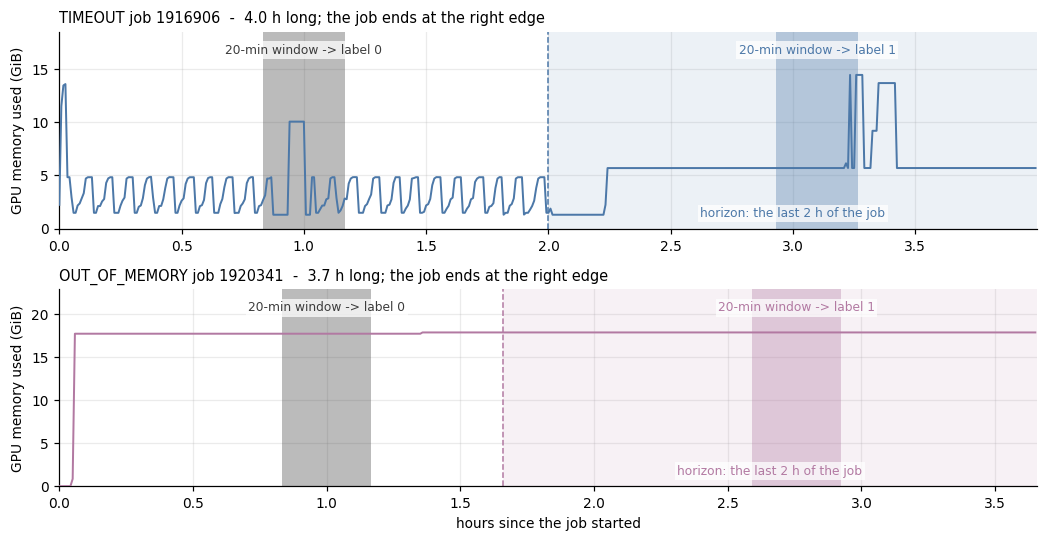

In [4]:
from matplotlib.transforms import blended_transform_factory

fig, axes = plt.subplots(2, 1, figsize=(9.6, 5.0))
win_h = WINDOW * SNAP_S / 3600                              # the window, 20 minutes in hours

for ax, (state, jid) in zip(axes, examples.items()):
    d   = ex[ex.slurm_id == jid]
    t0  = d.timestamp.iloc[0]
    T   = (d.end_date.iloc[0] - t0).total_seconds() / 3600  # job length in hours
    hrs = (d.timestamp - t0).dt.total_seconds() / 3600      # elapsed: the job ends on the right
    gb  = d[RAW_METRICS["gpu_mem_used"]] / 2**30
    blend = blended_transform_factory(ax.transData, ax.transAxes)   # x in data, y in axes

    # the horizon: inside it a window is labelled 1, outside it 0
    ax.axvspan(T - HORIZON_H, T, color=COLOR[state], alpha=0.10, lw=0)
    ax.axvline(T - HORIZON_H, color=COLOR[state], ls="--", lw=1.0)
    ax.text(T - HORIZON_H / 2, 0.06, f"horizon: the last {HORIZON_H:.0f} h of the job",
            transform=blend, ha="center", fontsize=8, color=COLOR[state],
            bbox=dict(fc="white", ec="none", alpha=0.75, pad=1.5))

    # one window on each side of that boundary
    for centre, lab, col in ((max(1.0, (T - HORIZON_H) * 0.5), "label 0", "#3c3c3c"),
                             (T - 0.9, "label 1", COLOR[state])):
        ax.axvspan(centre - win_h / 2, centre + win_h / 2, color=col, alpha=0.35, lw=0)
        ax.text(centre, 0.94, f"{WINDOW * SNAP_S / 60:.0f}-min window -> {lab}",
                transform=blend, ha="center", va="top", fontsize=8, color=col,
                bbox=dict(fc="white", ec="none", alpha=0.75, pad=1.5))

    ax.plot(hrs, gb, color=COLOR[state], lw=1.3, zorder=3)
    ax.set_xlim(0, T); ax.set_ylim(0, float(gb.max()) * 1.28)
    ax.set_ylabel("GPU memory used (GiB)")
    ax.set_title(f"{state} job {jid}  -  {T:.1f} h long; the job ends at the right edge",
                 loc="left", fontsize=9.5)

axes[-1].set_xlabel("hours since the job started")
fig.tight_layout()
save(fig, "09_window_diagram.png"); plt.show()

A 20-minute window is a narrow slice of a four-hour job - that in itself is worth seeing. A
model is handed one such slice and has to decide whether the job is inside its final two
hours, and nothing in the slice tells it how long the job has already been running: the 56
features are aggregations of the metrics and nothing else.

## 2. Building every window

One streaming pass. The metric columns are pulled straight from Arrow into a single
`float32` array rather than through pandas, which keeps peak memory near 2.5 GB instead of
6 GB. The window mechanics are vectorised over the whole sorted table with
`sliding_window_view`, so there is no Python loop over jobs: a candidate start is valid when
its 40th snapshot belongs to the same series, when the largest interval inside those 40
snapshots is at most `GAP_TOL_S`, and when its position inside the series is a multiple of
`STRIDE`.

In [5]:
t0 = time.time()
KEY_COLS = ["slurm_id", "node", "timestamp", "state", "end_date", "nodetypes", "numnodes"]
SRC = list(RAW_METRICS.values()) + list(CUM_METRICS.values())

tabs = []
for p in sorted(RAW.glob("part-*.parquet")):
    t = pq.read_table(p, columns=KEY_COLS + SRC + ["gpu_node"])
    t = t.filter((pc.field("gpu_node") == 1) & (pc.field("state") != "CANCELLED"))
    if t.num_rows:
        # float32 halves the footprint and is the precision the features are stored in
        t = t.drop_columns(["gpu_node"])
        t = t.cast(pa.schema([f.with_type(pa.float32()) if pa.types.is_floating(f.type)
                              else f for f in t.schema]))
        tabs.append(t)
tab = pa.concat_tables(tabs); del tabs; gc.collect()

keys = tab.select(KEY_COLS).to_pandas()
for c in ("node", "state", "nodetypes"):
    keys[c] = keys[c].astype("category")
order = np.lexsort((keys.timestamp.to_numpy(), keys.node.cat.codes.to_numpy(),
                    keys.slurm_id.to_numpy()))
keys = keys.iloc[order].reset_index(drop=True)

N = len(keys)
vals = np.empty((N, len(METRICS)), dtype=np.float32)
for j, m in enumerate(RAW_METRICS):
    vals[:, j] = tab.column(RAW_METRICS[m]).to_numpy(zero_copy_only=False)[order]
cum = {m: tab.column(src).to_numpy(zero_copy_only=False)[order].astype(np.float64)
       for m, src in CUM_METRICS.items()}
del tab; gc.collect()
print(f"loaded {N:,} snapshots in {time.time()-t0:.0f}s")

loaded 11,144,842 snapshots in 19s


In [6]:
# --- series ids, time to end, per-snapshot label ---------------------------
sid = keys.slurm_id.astype(np.int64).to_numpy() * 1000 + keys.node.cat.codes.to_numpy()
is_new_series = np.empty(N, bool); is_new_series[0] = True
is_new_series[1:] = sid[1:] != sid[:-1]
series = np.cumsum(is_new_series) - 1

ts_ns = keys.timestamp.astype("int64").to_numpy()
ttf = (keys.end_date.astype("int64").to_numpy() - ts_ns) / 1e9      # seconds to job end
snap_pos = (keys.state.isin(FAILURE_STATES).to_numpy()
            & (ttf >= 0) & (ttf <= HORIZON_H * 3600)).astype(np.int32)

# --- cumulative counters -> per-second rates -------------------------------
dt = np.diff(ts_ns) / 1e9
for k, (m, x) in enumerate(cum.items()):
    r = np.zeros(N)
    step = np.where(dt > 0, dt, np.nan)
    r[1:] = np.clip(np.diff(x) / step, 0, None)   # a negative step is a counter reset
    r[~np.isfinite(r)] = 0.0
    r[is_new_series] = 0.0                        # no predecessor inside this series
    vals[:, len(RAW_METRICS) + k] = r.astype(np.float32)
del cum; gc.collect()

# --- which window starts are valid ----------------------------------------
n_cand = N - WINDOW + 1
start = np.arange(n_cand)
same_series = series[start] == series[start + WINDOW - 1]
max_gap = np.lib.stride_tricks.sliding_window_view(dt, WINDOW - 1).max(axis=1)[:n_cand]
pos_in_series = start - np.searchsorted(series, series[start], side="left")
ok = same_series & (max_gap <= GAP_TOL_S) & (pos_in_series % STRIDE == 0)
starts = np.flatnonzero(ok)

print(f"candidate starts   {n_cand:,}")
print(f"  same series      {int(same_series.sum()):,}")
print(f"  gap-free         {int((same_series & (max_gap <= GAP_TOL_S)).sum()):,}")
print(f"  kept after stride{len(starts):>12,}")

candidate starts   11,144,803
  same series      10,535,156
  gap-free         10,512,402
  kept after stride   1,057,817


In [7]:
# --- aggregate each window -------------------------------------------------
sw = np.lib.stride_tricks.sliding_window_view(vals, WINDOW, axis=0)   # (n_cand, M, W) view
X = np.empty((len(starts), len(FEATURES)), dtype=np.float32)
for a in range(0, len(starts), 50_000):
    sub = sw[starts[a:a + 50_000]]                                    # (c, M, W)
    stacked = np.stack([sub.min(-1), sub.max(-1), sub.mean(-1), sub.std(-1)], axis=2)
    X[a:a + len(sub)] = stacked.reshape(len(sub), -1)                 # metric-major
del sw, vals; gc.collect()

# --- labels: majority vote over the 40 snapshots ---------------------------
csum = np.concatenate([[0], np.cumsum(snap_pos)])
n_pos_in_window = csum[starts + WINDOW] - csum[starts]
y = (n_pos_in_window >= WINDOW / 2).astype(np.int8)

last = starts + WINDOW - 1                       # the window's final snapshot
W = pd.DataFrame(X, columns=FEATURES)
W.insert(0, "y", y)
W.insert(0, "n_pos", n_pos_in_window.astype(np.int16))
W.insert(0, "ttf_end", ttf[last].astype(np.float32))   # seconds from window end to job end
W.insert(0, "t_end", keys.timestamp.to_numpy()[last])
W.insert(0, "numnodes", keys.numnodes.to_numpy()[last])
W.insert(0, "nodetypes", keys.nodetypes.to_numpy()[last])
W.insert(0, "state", keys.state.to_numpy()[last])
W.insert(0, "node", keys.node.to_numpy()[last])
W.insert(0, "slurm_id", keys.slurm_id.to_numpy()[last])
W["split"] = np.where(W.slurm_id.isin(set(jobs.loc[jobs.split == "train", "slurm_id"])),
                      "train", "test")
print(f"built {W.shape[0]:,} windows x {len(FEATURES)} features in {time.time()-t0:.0f}s")

built 1,057,817 windows x 56 features in 32s


In [8]:
# --- invariants: every one of these must hold ------------------------------
assert (max_gap[starts] <= GAP_TOL_S).all(), "a window spans a gap"
assert (series[starts] == series[starts + WINDOW - 1]).all(), "a window crosses two series"
assert W.loc[W.y == 1, "state"].isin(FAILURE_STATES).all(), "a positive on a healthy job"
assert (W.n_pos >= WINDOW / 2).eq(W.y == 1).all(), "label disagrees with the vote"
tr_end = jobs.loc[jobs.split == "train", "end_date"].max()
te_end = jobs.loc[jobs.split == "test", "end_date"].min()
assert tr_end <= te_end, "the temporal split overlaps"
print("all invariants hold")

# ttf_end can be slightly negative: telemetry sometimes emits one snapshot after
# the recorded end_date. Report it rather than hiding it.
late = (W.ttf_end < 0).sum()
print(f"windows ending after the job's recorded end_date: {late:,} ({late/len(W):.4%})")

W.to_parquet(DATA / "windows.parquet", index=False)
print(f"data/windows.parquet  {(DATA/'windows.parquet').stat().st_size/1e6:.0f} MB")

all invariants hold
windows ending after the job's recorded end_date: 0 (0.0000%)


data/windows.parquet  126 MB


## 3. The window census

The number to notice is the positive *rate*. At job level 26.7 % of jobs fail; at window
level only about 3 % of rows are positive, because a failing job is mostly made of ordinary
windows and only its last two hours count. That 3 % is the baseline every precision figure
later has to be read against: a classifier guessing at random achieves a precision equal to
it.

In [9]:
census = W.groupby("state", observed=True).agg(
    windows=("y", "size"), positives=("y", "sum"), positive_rate=("y", "mean"),
    jobs=("slurm_id", "nunique")).reindex(STATES)
print(census.to_string(formatters={"positive_rate": "{:.2%}".format}))

print(f"\ntotal windows      {len(W):,}")
print(f"positive windows   {int(W.y.sum()):,}  ({W.y.mean():.2%})")
print(f"jobs represented   {W.slurm_id.nunique():,} of {len(jobs):,} "
      f"({W.slurm_id.nunique()/len(jobs):.1%})")
print("\nby split:")
print(W.groupby("split").y.agg(windows="size", positives="sum",
                               positive_rate="mean").to_string(
      formatters={"positive_rate": "{:.2%}".format}))

               windows  positives positive_rate   jobs
state                                                 
COMPLETED       630123          0         0.00%  10862
FAILED           58822       9491        16.14%    713
TIMEOUT         359358      24926         6.94%   1291
OUT_OF_MEMORY     6981        830        11.89%     57
NODE_FAIL         2533        418        16.50%     36

total windows      1,057,817
positive windows   35,665  (3.37%)
jobs represented   12,959 of 23,618 (54.9%)

by split:
       windows  positives positive_rate
split                                  
test    142309       5826         4.09%
train   915508      29839         3.26%


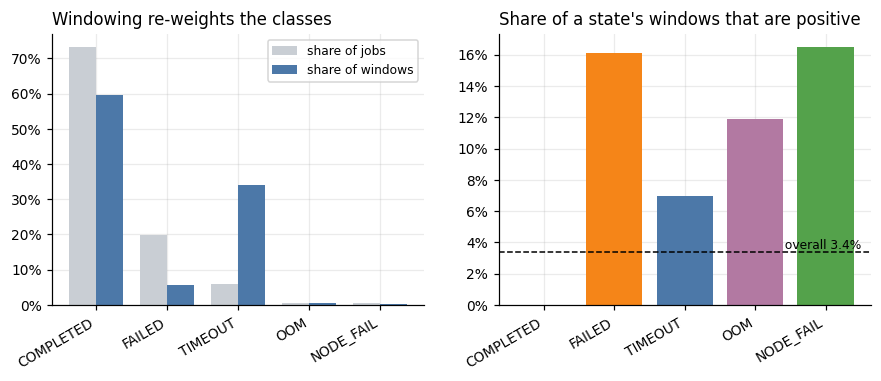

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))
ax = axes[0]
share_jobs = jobs.state.value_counts(normalize=True).reindex(STATES)
share_win = census.windows / census.windows.sum()
x = np.arange(len(STATES)); w = 0.38
ax.bar(x - w/2, share_jobs.values, w, label="share of jobs", color="#c9ced4")
ax.bar(x + w/2, share_win.values, w, label="share of windows", color="#4c78a8")
ax.set_xticks(x, [s.replace("OUT_OF_MEMORY", "OOM") for s in STATES], rotation=30, ha="right")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(fontsize=8); ax.set_title("Windowing re-weights the classes", loc="left")

ax = axes[1]
r = census.positive_rate.fillna(0)
ax.bar(range(len(r)), r.values, color=[COLOR[s] for s in r.index])
ax.axhline(W.y.mean(), color="k", ls="--", lw=1)
ax.text(len(r) - .5, W.y.mean(), f" overall {W.y.mean():.1%}", fontsize=8, va="bottom", ha="right")
ax.set_xticks(range(len(r)), [s.replace("OUT_OF_MEMORY", "OOM") for s in r.index],
              rotation=30, ha="right")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Share of a state's windows that are positive", loc="left")
save(fig, "10_window_census.png"); plt.show()

# Part 2 - What the rows contain

## 4. Is the label determined by the features?

Notebook 01 found that 78 % of snapshots are shared between concurrent jobs on one node, and
that the telemetry attached to them is byte-identical. The question here is what that does
to the *windows*: two co-tenant jobs produce rows with identical features and possibly
opposite labels, and a classifier that answers deterministically from those features has to
be wrong on one of them.

One measurement trap, worth stating because it is easy to fall into. Matching the *kept*
windows against each other - looking for two rows with the same `(node, t_end)` - badly
undercounts: with `STRIDE = 10`, two co-tenants whose series began at different offsets
almost never have a kept window ending on the same timestamp. Measured that way the sharing
rate reads 16 % rather than 78 %, purely as an artefact of the subsampling. Concurrency is
therefore measured on the **snapshot grid**, where it is exact, and read off at the window
level.

In [11]:
# Identify the physical telemetry row each snapshot came from: one row per
# (node, timestamp), shared by every job running there at that moment.
row_key = (ts_ns // 1_000_000_000) * 64 + keys.node.cat.codes.to_numpy().astype(np.int64)
_, inv = np.unique(row_key, return_inverse=True)
n_at_row   = np.bincount(inv).astype(np.int32)[inv]                    # jobs on this row
pos_at_row = np.bincount(inv, weights=snap_pos).astype(np.int32)[inv]  # of which positive

yv = W.y.to_numpy()
P = int(yv.sum())
others     = n_at_row[last] - 1                    # co-tenants when the warning would fire
others_pos = pos_at_row[last] - snap_pos[last]
shared     = others > 0
contra_pos = (yv == 1) & (others - others_pos > 0)
contra_neg = (yv == 0) & (others_pos > 0)

print(f"distinct telemetry rows: {inv.max() + 1:,} for {len(keys):,} snapshots")
print()
print("measured at the window's final snapshot - the moment a warning would fire")
print(f"  windows whose feature row is shared with another job: {shared.mean():>7.1%}")
print(f"  positive windows with a NON-failing co-tenant       : {int(contra_pos.sum()):>7,} "
      f"of {P:,} ({contra_pos.sum()/P:.1%})")
print(f"  negative windows with a FAILING co-tenant           : {int(contra_neg.sum()):>7,} "
      f"({contra_neg.mean():.2%} of all windows)")

# Stricter: require the co-tenant to be present for all 40 snapshots, so the two
# jobs share the entire feature vector rather than only its last row.
min_conc = np.lib.stride_tricks.sliding_window_view(n_at_row, WINDOW).min(axis=1)[starts]
min_neg = np.lib.stride_tricks.sliding_window_view(
    n_at_row - pos_at_row, WINDOW).min(axis=1)[starts]
print()
print("requiring the co-tenant to be present for the whole 20-minute window")
print(f"  windows sharing their entire feature vector         : {(min_conc > 1).mean():>7.1%}")
print(f"  positive windows whose identical twin is negative   : "
      f"{((yv == 1) & (min_neg > 0)).sum()/P:>7.1%}")

ex_q = W.nodetypes.isin(["gpu", "gpu_titanrtx"]).to_numpy()
print()
print(f"exclusive queues: {int(ex_q.sum()):,} windows ({ex_q.mean():.1%}), "
      f"positive rate {yv[ex_q].mean():.2%}, shared rows {shared[ex_q].mean():.1%}")
CEILING = 1 - contra_pos.sum() / P
print()
print(f"=> recall ceiling from node-level features: about {CEILING:.0%}")

distinct telemetry rows: 5,392,404 for 11,144,842 snapshots

measured at the window's final snapshot - the moment a warning would fire
  windows whose feature row is shared with another job:   78.2%
  positive windows with a NON-failing co-tenant       :  19,976 of 35,665 (56.0%)
  negative windows with a FAILING co-tenant           :  35,973 (3.40% of all windows)



requiring the co-tenant to be present for the whole 20-minute window
  windows sharing their entire feature vector         :   77.5%
  positive windows whose identical twin is negative   :   54.3%

exclusive queues: 100,135 windows (9.5%), positive rate 3.09%, shared rows 0.0%

=> recall ceiling from node-level features: about 44%


About **56 % of positive windows** carry a feature row that also belongs to a job which is
not failing, and for 54 % that co-tenant is present for the entire 20 minutes: the two jobs
are handed the same 56 numbers and given opposite labels. That is a ceiling near **44 %** on
recall, set by the data rather than by the algorithm, and the 3.4 % of negative windows
sitting beside a failing co-tenant cap precision the same way. Only the exclusive queues
(`gpu`, `gpu_titanrtx`) escape it, at the cost of 90 % of the windows.

A ceiling is not an answer, though. It says a perfect model would still miss half the
positives; it says nothing about whether the other half is separable at all. That is the
next question.

## 5. Does any single feature separate the classes?

The cheapest possible model: rank every window by one feature and ask how often a positive
outranks a negative. That is exactly the area under the ROC curve for that feature, and it
can be read off the ranks with nothing trained.

`AUC = 0.5` means the feature is useless. We report `|AUC - 0.5|`, so that a feature which
is informative in the negative direction (lower is riskier) ranks alongside one that is
informative in the positive direction.

scored on 300,000 sampled windows (10,249 positive)


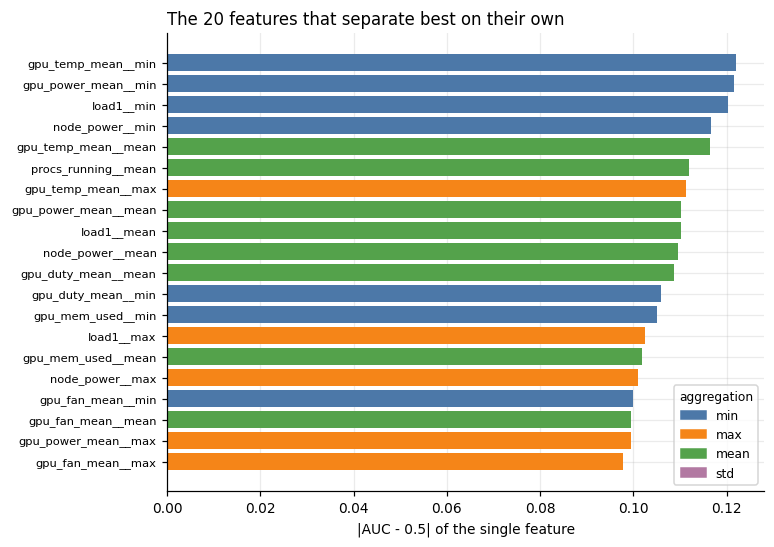


mean |AUC-0.5| by aggregation:
mean    0.071311
min     0.070278
max     0.069213
std     0.030685

mean |AUC-0.5| by metric group:
gpu       0.084753
load      0.067814
io        0.034388
memory    0.027136


In [12]:
from scipy.stats import rankdata

rng = np.random.default_rng(42)
idx = rng.choice(len(W), size=min(300_000, len(W)), replace=False)
ys = W.y.to_numpy()[idx]
n_pos, n_neg = int(ys.sum()), int((1 - ys).sum())
print(f"scored on {len(idx):,} sampled windows ({n_pos:,} positive)")

auc = {}
for f in FEATURES:
    r = rankdata(W[f].to_numpy()[idx])
    auc[f] = (r[ys == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
auc = pd.Series(auc)
sep = (auc - 0.5).abs().sort_values(ascending=False)

top = sep.head(20)[::-1]
fig, ax = plt.subplots(figsize=(7.0, 5.4))
from matplotlib.patches import Patch
AGG_COLOR = {"min": "#4c78a8", "max": "#f58518", "mean": "#54a24b", "std": "#b279a2"}
ax.barh(range(len(top)), top.values,
        color=[AGG_COLOR[f.split("__")[1]] for f in top.index])
ax.set_yticks(range(len(top)), top.index, fontsize=7.5)
ax.set_xlabel("|AUC - 0.5| of the single feature")
handles = [Patch(color=c, label=a) for a, c in AGG_COLOR.items()]
ax.legend(handles=handles, fontsize=8, title="aggregation", title_fontsize=8)
ax.set_title("The 20 features that separate best on their own", loc="left")
save(fig, "12_separability.png"); plt.show()

print("\nmean |AUC-0.5| by aggregation:")
print(sep.groupby([f.split("__")[1] for f in sep.index]).mean().sort_values(
    ascending=False).to_string())
print("\nmean |AUC-0.5| by metric group:")
print(sep.groupby([GROUP[f.split("__")[0]] for f in sep.index]).mean().sort_values(
    ascending=False).to_string())

The best of the 56 features reaches `|AUC - 0.5| = 0.12`, and the median reaches 0.05. There
is no column a threshold could usefully be placed on: whatever a model finds here has to be
weak and multivariate.

Two details matter later. `std` separates least of the four aggregations - the one
aggregation that needs a long window is the one carrying the least information, which makes
a shorter window a cheap trade. And GPU metrics separate about three times better than
memory ones.

The box plots below are the same result seen directly: the view suggested by the professor,
with all four aggregations of a metric split by the job's end state. All 14 metrics are
written to `figures/`; the best-separating one and one from the middle of the ranking are
shown here, plus one split by the window label rather than by the state, which is the
comparison a classifier actually faces. Boxes span the interquartile range, whiskers the
5th to 95th percentile, outliers are hidden (with a million windows they would swamp the
boxes), and the count above each box is how many windows it summarises - OOM and NODE_FAIL
have three orders of magnitude fewer than COMPLETED.

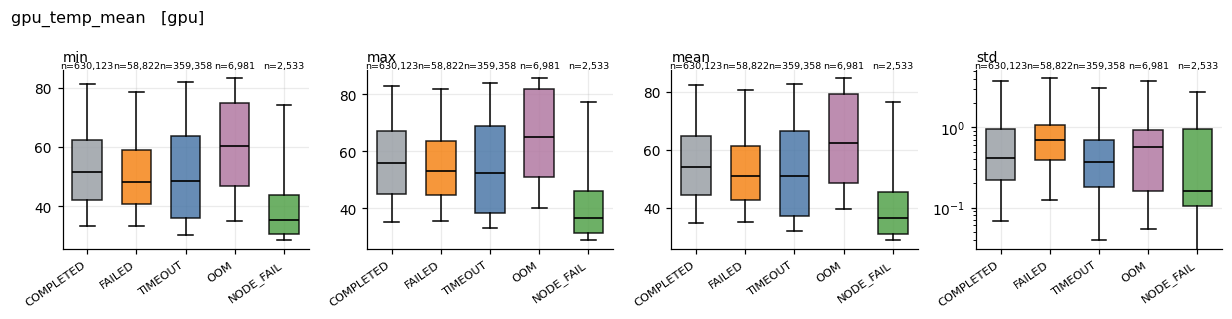

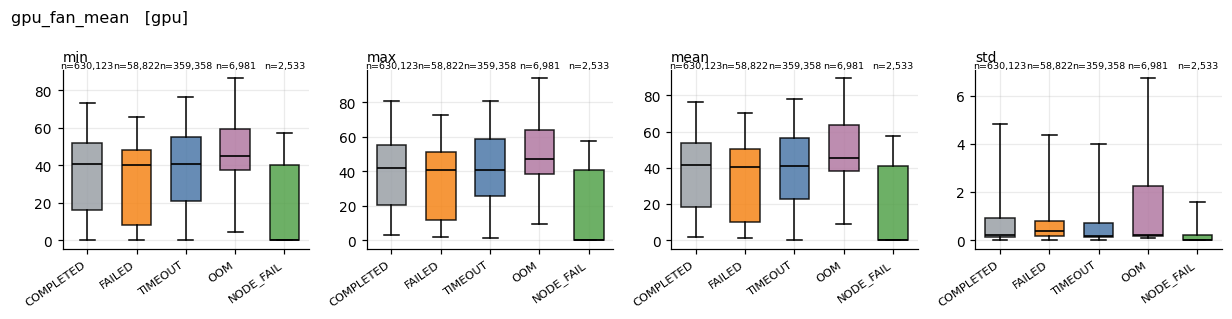

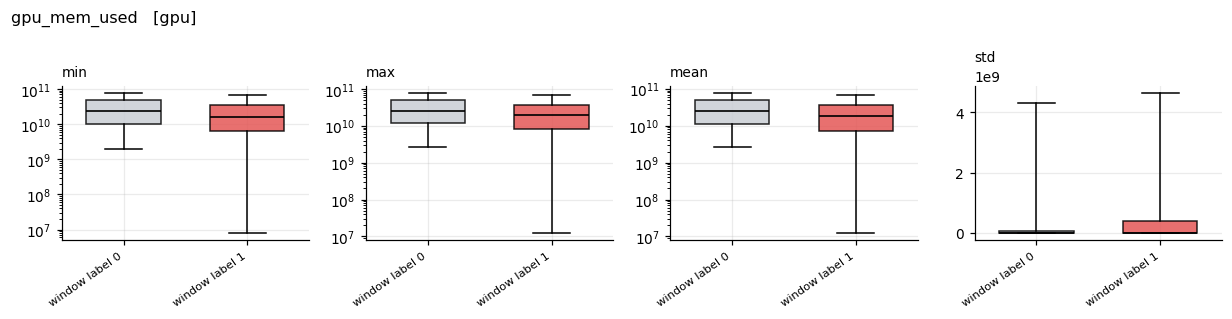

In [13]:
def boxplot_metric(metric, by="state"):
    """4 panels (min/max/mean/std) for one metric, grouped by state or by label."""
    if by == "state":
        groups = [(s, W.state == s) for s in STATES]
        labels = [s.replace("OUT_OF_MEMORY", "OOM") for s in STATES]
        colors = [COLOR[s] for s in STATES]
    else:
        groups = [("negative", W.y == 0), ("positive", W.y == 1)]
        labels = ["window label 0", "window label 1"]
        colors = ["#c9ced4", "#e45756"]

    fig, axes = plt.subplots(1, 4, figsize=(11.2, 2.9))
    for ax, agg in zip(axes, AGGS):
        col = W[f"{metric}__{agg}"].to_numpy()
        data = [col[m.to_numpy()] for _, m in groups]
        bp = ax.boxplot(data, whis=(5, 95), showfliers=False, patch_artist=True,
                        medianprops=dict(color="black", lw=1.1), widths=0.6)
        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c); patch.set_alpha(0.85)
        ax.set_xticks(range(1, len(data) + 1), labels, rotation=35, ha="right", fontsize=7.5)
        ax.set_title(agg, loc="left", fontsize=9)
        # log scale only when it helps and is legal
        flat = col[np.isfinite(col)]
        pos = flat[flat > 0]
        if len(pos) > 0.9 * len(flat) and pos.max() / max(np.percentile(pos, 1), 1e-12) > 500:
            ax.set_yscale("log")
        if by == "state":
            top = ax.get_ylim()[1]
            for i, d in enumerate(data, start=1):
                ax.text(i, top, f"n={len(d):,}", ha="center", va="bottom", fontsize=6.2,
                        rotation=0)
    fig.suptitle(f"{metric}   [{GROUP[metric]}]", x=0.005, ha="left", fontsize=10.5)
    fig.tight_layout()
    return fig

# All 14 metrics are written to figures/; two are displayed - the feature that separates
# best on its own, and one from the middle of the ranking.
SHOW = {sep.index[0].split("__")[0], sep.index[len(sep) // 2].split("__")[0]}
for m in METRICS:
    fig = save(boxplot_metric(m), f"box_{m}.png")
    if m in SHOW:
        plt.show()
    else:
        plt.close(fig)

# The same metrics split by the window label instead of by the end state.
for m in ["mem_free", "gpu_mem_used", "gpu_duty_mean"]:
    fig = save(boxplot_metric(m, by="label"), f"box_bylabel_{m}.png")
    if m == "gpu_mem_used":
        plt.show()
    else:
        plt.close(fig)

## 6. How many independent features are there?

Fifty-six columns are not fifty-six independent pieces of evidence. `min`, `max` and `mean`
of a slowly-varying metric are nearly the same number, and several metrics move together
because they all reflect how busy the node is. This is what decides how to read section 5: a
weak best feature would be far less discouraging if the other 55 were independent attempts.

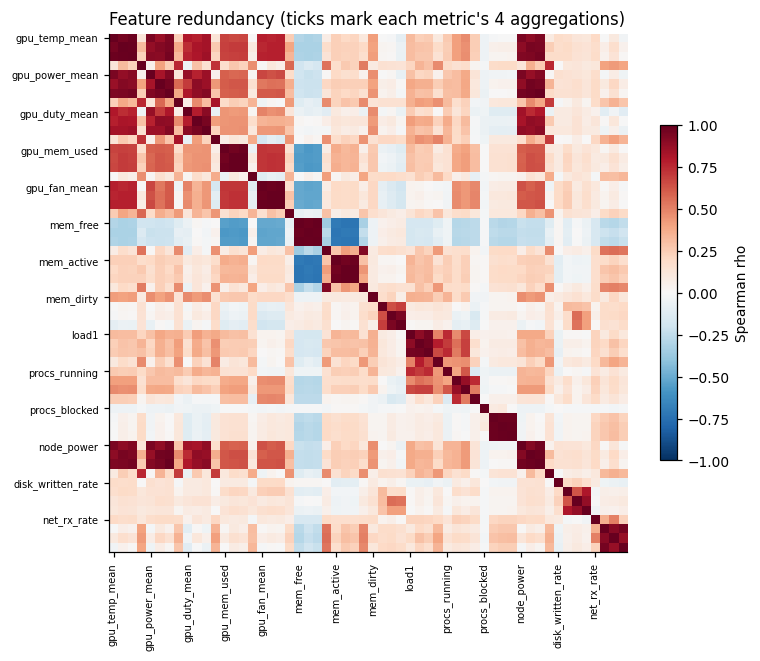

features with |rho| > 0.95 against at least one other: 30 of 56
mean |rho| between the 4 aggregations of the same metric: 0.59


In [14]:
sub = W[FEATURES].to_numpy()[rng.choice(len(W), size=50_000, replace=False)]
ranks = np.apply_along_axis(rankdata, 0, sub)
C = np.corrcoef(ranks, rowvar=False)          # Spearman

fig, ax = plt.subplots(figsize=(7.6, 6.6))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(0, len(FEATURES), 4),
              [FEATURES[i].split("__")[0] for i in range(0, len(FEATURES), 4)],
              rotation=90, fontsize=6.5)
ax.set_yticks(range(0, len(FEATURES), 4),
              [FEATURES[i].split("__")[0] for i in range(0, len(FEATURES), 4)], fontsize=6.5)
ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.6, label="Spearman rho")
ax.set_title("Feature redundancy (ticks mark each metric's 4 aggregations)", loc="left")
save(fig, "13_redundancy.png"); plt.show()

off = C - np.eye(len(C))
near_dup = (np.abs(off) > 0.95).any(axis=1)
print(f"features with |rho| > 0.95 against at least one other: "
      f"{int(near_dup.sum())} of {len(FEATURES)}")
print(f"mean |rho| between the 4 aggregations of the same metric: "
      f"{np.mean([abs(C[i, j]) for m in range(len(METRICS)) for i in range(4*m, 4*m+4) for j in range(4*m, 4*m+4) if i != j]):.2f}")

Thirty of the 56 have a near-duplicate elsewhere in the table, and the four aggregations of
one metric correlate at 0.59 on average. The effective width of this feature set is closer
to twenty columns than to fifty-six, so the weak separability above is not the result of
having looked in too few places.

## 7. Do the features move as the job approaches its end?

A window is a static summary, so a weak single-feature AUC is still consistent with a strong
*trajectory*: every failing job could drift hard in its final hours while the class medians
stay close together. That drift is the premise of the whole project, and it can be checked
without a model - plot the median of a metric against how long is left until the job ends,
one line per state.

Values are standardised per node first (subtract the node's median, divide by its IQR),
because nodes differ in absolute level and what matters is the shape of the trajectory, not
the offset. The six metrics plotted are the best-separating ones from section 5.

metrics plotted: ['gpu_temp_mean', 'gpu_power_mean', 'load1', 'node_power', 'procs_running', 'gpu_duty_mean']


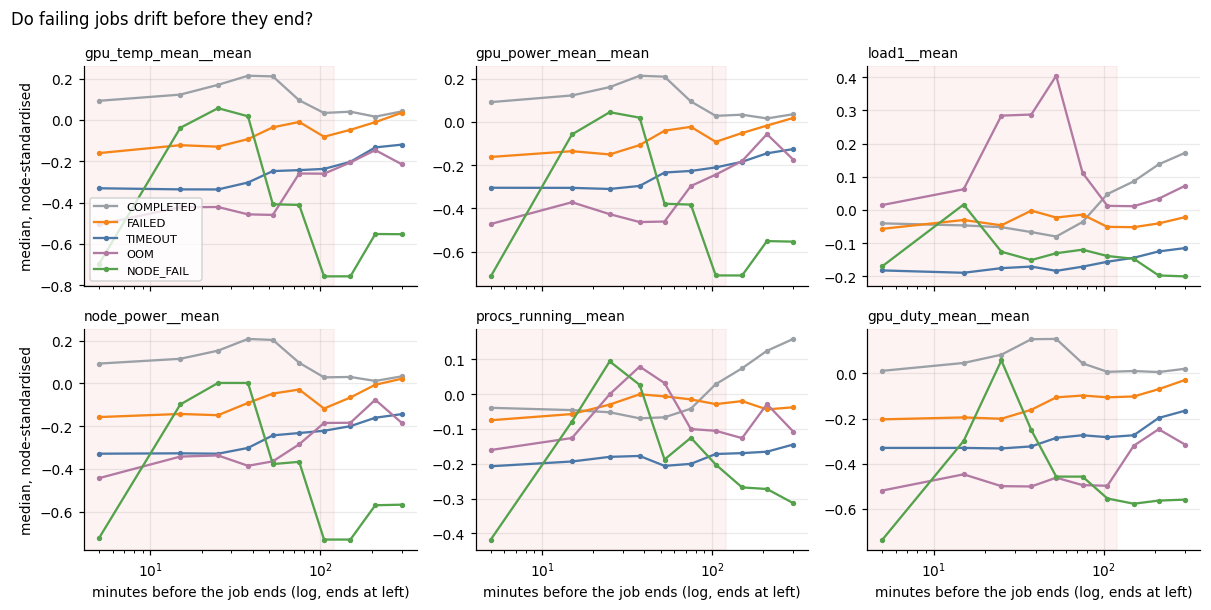

In [15]:
best_metrics = list(dict.fromkeys(f.split("__")[0] for f in sep.index))[:6]
print("metrics plotted:", best_metrics)

edges = np.array([0, 10, 20, 30, 45, 60, 90, 120, 180, 240, 360]) * 60   # seconds
centres = (edges[:-1] + edges[1:]) / 2 / 60
bin_id = np.digitize(W.ttf_end.to_numpy(), edges) - 1

fig, axes = plt.subplots(2, 3, figsize=(11.0, 5.6), sharex=True)
for ax, m in zip(axes.ravel(), best_metrics):
    col = f"{m}__mean"
    v = W[col].to_numpy().astype(np.float64)
    nid = W.node.astype(str).to_numpy()
    df = pd.DataFrame({"v": v, "n": nid})
    med = df.groupby("n").v.transform("median")
    iqr = df.groupby("n").v.transform(lambda s: s.quantile(.75) - s.quantile(.25))
    zv = (v - med.to_numpy()) / np.where(iqr.to_numpy() > 0, iqr.to_numpy(), 1.0)

    for s in STATES:
        msk = (W.state == s).to_numpy() & (bin_id >= 0) & (bin_id < len(centres))
        if msk.sum() < 200:
            continue
        prof = pd.Series(zv[msk]).groupby(bin_id[msk]).median()
        ax.plot(centres[prof.index], prof.values, color=COLOR[s], lw=1.5, marker="o",
                ms=2.5, label=s.replace("OUT_OF_MEMORY", "OOM"))
    ax.invert_xaxis(); ax.set_xscale("log")
    ax.set_title(col, loc="left", fontsize=9)
    ax.axvspan(0, HORIZON_H * 60, color="#e45756", alpha=0.07)
axes[0, 0].legend(fontsize=7.5)
for ax in axes[-1]:
    ax.set_xlabel("minutes before the job ends (log, ends at left)")
for ax in axes[:, 0]:
    ax.set_ylabel("median, node-standardised")
fig.suptitle("Do failing jobs drift before they end?", x=0.005, ha="left")
fig.tight_layout()
save(fig, "14_precursors.png"); plt.show()

The shaded band on the right of each panel is the 2-hour horizon, the region labelled
positive. A precursor would show up as a failure line pulling away from the grey COMPLETED
line and continuing to move as the end approaches.

That is mostly not what the panels show. `TIMEOUT` and `FAILED` sit below `COMPLETED` by a
roughly constant offset from six hours out to five minutes out: the lines are separated, but
they are *flat*. What the features report is what kind of job this is - how hard it drives
the GPU - rather than that something is about to go wrong with it. This is the mechanism
behind section 5, and it is why the wider horizons in section 8 add positives without adding
information.

Two states do move. `NODE_FAIL` collapses across every power, temperature and utilisation
panel in the last ten to fifteen minutes, which is what a machine going down looks like; the
lead time that offers is minutes, not hours, and it is measured on 36 jobs. `OUT_OF_MEMORY`
shows a `load1` rise peaking roughly 40 minutes before the end. Both are real precursors, and
both live on the two smallest states in the dataset.

## 8. Would a different horizon change the answer?

The horizon is a free parameter, and the only part of the label that is ours rather than the
data's. Because every window stores `ttf_end` - the seconds from its last snapshot to the
job's end - the label can be recomputed for any horizon in closed form, with no rebuild: the
40 snapshots sit on an even 30-second grid (guaranteed by the gap rule), so counting how many
of them fall inside a horizon is arithmetic. The cell below checks the closed form against
the labels actually built, then sweeps the horizon.

In [16]:
def relabel(ttf_end, state, horizon_h, window=WINDOW, snap_s=SNAP_S,
            positive_states=FAILURE_STATES):
    """Window labels for any horizon, computed from ttf_end alone."""
    ttf = np.asarray(ttf_end, dtype=np.float64)
    j_hi = np.floor((horizon_h * 3600 - ttf) / snap_s)     # last snapshot inside horizon
    j_lo = np.ceil(np.maximum(0.0, -ttf) / snap_s)         # first snapshot with ttf >= 0
    n_in = np.clip(j_hi - j_lo + 1.0, 0.0, float(window))
    return ((n_in >= window / 2) & pd.Series(state).isin(positive_states).to_numpy()).astype(np.int8)

check = relabel(W.ttf_end, W.state, HORIZON_H)
agree = (check == W.y.to_numpy()).mean()
print(f"closed-form relabel reproduces the built labels for {agree:.4%} of windows")
assert agree > 0.999, "the closed form disagrees with the labels built from snapshots"

rows = []
for h in (0.25, 0.5, 1.0, 2.0, 4.0, 6.0, 12.0):
    yh = relabel(W.ttf_end, W.state, h)
    row = {"horizon_h": h, "positives": int(yh.sum()), "positive_rate": yh.mean()}
    for s in FAILURE_STATES:
        row[s] = int(yh[(W.state == s).to_numpy()].sum())
    rows.append(row)
hz = pd.DataFrame(rows)
print()
print(hz.to_string(index=False, formatters={"positive_rate": "{:.2%}".format}))

closed-form relabel reproduces the built labels for 100.0000% of windows



 horizon_h  positives positive_rate  FAILED  TIMEOUT  OUT_OF_MEMORY  NODE_FAIL
      0.25       2731         0.26%     765     1885             56         25
      0.50       8439         0.80%    2515     5628            197         99
      1.00      18704         1.77%    5281    12742            436        245
      2.00      35665         3.37%    9491    24926            830        418
      4.00      62020         5.86%   15774    44250           1337        659
      6.00      84085         7.95%   20509    60945           1732        899
     12.00     140829        13.31%   31094   105646           2533       1556


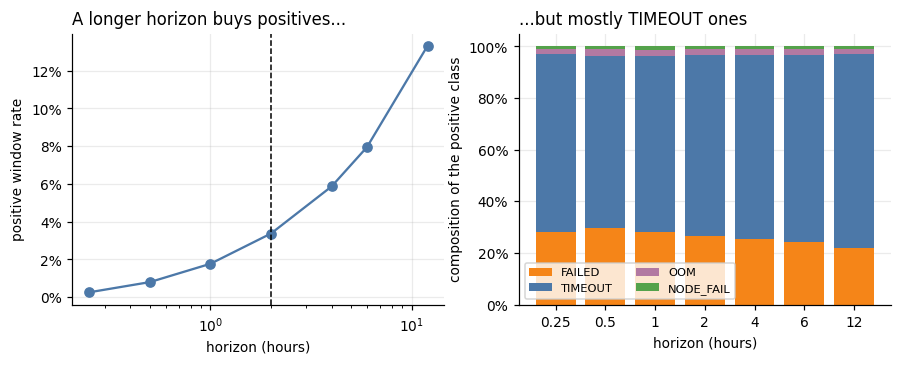

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))
ax = axes[0]
ax.plot(hz.horizon_h, hz.positive_rate, marker="o", color="#4c78a8")
ax.axvline(HORIZON_H, color="k", ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("horizon (hours)"); ax.set_ylabel("positive window rate")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("A longer horizon buys positives...", loc="left")

ax = axes[1]
bottom = np.zeros(len(hz))
for s in FAILURE_STATES:
    ax.bar(range(len(hz)), hz[s] / hz.positives, bottom=bottom, color=COLOR[s],
           label=s.replace("OUT_OF_MEMORY", "OOM"))
    bottom += (hz[s] / hz.positives).to_numpy()
ax.set_xticks(range(len(hz)), [f"{h:g}" for h in hz.horizon_h])
ax.set_xlabel("horizon (hours)"); ax.set_ylabel("composition of the positive class")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(fontsize=7.5, ncols=2)
ax.set_title("...but mostly TIMEOUT ones", loc="left")
save(fig, "15_horizon.png"); plt.show()

Widening the horizon does raise the positive rate, but it does so by adding `TIMEOUT`
windows: a long job has many windows inside any horizon and a short one has none. Beyond a
few hours the positive class is essentially "a long job that will hit its walltime", which is
a different prediction problem from node health - and by section 7 those extra windows come
from the flat part of the trajectory. Two hours is a reasonable compromise: enough positives
to train on, still short enough that a warning would be actionable.

## Summary

In [18]:
facts = {
    "windows built": f"{len(W):,}",
    "features per window": f"{len(FEATURES)} ({len(METRICS)} metrics x {len(AGGS)} aggs)",
    "jobs represented": f"{W.slurm_id.nunique():,} of {len(jobs):,}",
    "window positive rate": f"{W.y.mean():.2%}",
    "positive rate, train / test": f"{W[W.split=='train'].y.mean():.2%} / {W[W.split=='test'].y.mean():.2%}",
    "windows discarded for spanning a gap":
        f"{int(same_series.sum() - (same_series & (max_gap <= GAP_TOL_S)).sum()):,}",
    "windows sharing their feature row with another job": f"{shared.mean():.1%}",
    "positive windows contradicted by a co-tenant": f"{contra_pos.sum()/P:.1%}",
    "recall ceiling from node-level features": f"{CEILING:.0%}",
    "best single-feature |AUC-0.5|": f"{sep.iloc[0]:.3f} ({sep.index[0]})",
    "median single-feature |AUC-0.5|": f"{sep.median():.3f}",
    "features with |rho|>0.95 to another": f"{int(near_dup.sum())} of {len(FEATURES)}",
}
for k, v in facts.items():
    print(f"  {k:<45} {v}")
json.dump(facts, open(DATA / "facts_02.json", "w"), indent=2)

  windows built                                 1,057,817
  features per window                           56 (14 metrics x 4 aggs)
  jobs represented                              12,959 of 23,618
  window positive rate                          3.37%
  positive rate, train / test                   3.26% / 4.09%
  windows discarded for spanning a gap          22,754
  windows sharing their feature row with another job 78.2%
  positive windows contradicted by a co-tenant  56.0%
  recall ceiling from node-level features       44%
  best single-feature |AUC-0.5|                 0.122 (gpu_temp_mean__min)
  median single-feature |AUC-0.5|               0.053
  features with |rho|>0.95 to another           30 of 56


### What this notebook establishes

The four questions, in the order they were asked:

1. **The label is only partly determined by the features.** 56 % of positive windows share
   their feature row with a co-tenant job that does not fail, which caps recall near 44 %
   whatever the model. Only the exclusive queues escape it.
2. **No single feature separates the classes**, the best reaching `|AUC - 0.5| = 0.12`, and
   the 56 features amount to roughly twenty independent ones.
3. **The separation that does exist is a level, not a trajectory.** Failing and completing
   jobs are offset from each other hours before the end, and the offset barely moves as the
   end approaches. `NODE_FAIL` and `OUT_OF_MEMORY` are the exceptions, and they are the two
   smallest states.
4. **A wider horizon does not change that**, because the windows it adds are `TIMEOUT`
   windows from the flat part of the trajectory.

The mechanics themselves are sound: about a million windows, 3 % of them positive, every one
gap-free and confined to a single job on a single node, with labels that the closed-form
horizon formula reproduces exactly.

Notebook 03 turns these properties into a statement about which use case the pipeline can
serve.